In [32]:
pip install nbformat


   ----------- ---------------------------- 2/7 [attrs]
   ----------------- ---------------------- 3/7 [referencing]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------------- 7/7 [nbformat]

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
%run Funcions.ipynb

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Note: you may need to restart the kernel to use updated packages.


# MELINA

## Lectura de Dades

In [50]:
import csv

# Path .csv
file = "C:/Users/Usuario/Documents/Convolucio/DesignExpert_results_ronda2_rawdata.csv"

#obri les dades, utililtizant ";"  com a delimitador, i ho carrega en la llista "data"
with open(file, newline="", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=";")
    data = list(reader)

# Stores data
header = data[1]
rows = data[0:]
columns = list(zip(*rows)) #trasposa les dades (zip(rows)) per a convertir les files en columnes,

In [51]:
## Creates Collection
designexpert_sampling = Collection("DesignExpert-Sampling")
print(designexpert_sampling)

-- Melina DLS Collection --
NAME     : DesignExpert-Sampling
Experiments : 0



In [4]:
#debug es el proces de trobar i corregir errors, i mostra que está passant dins del codi 
# si debug = 0, no imprimeix missatges intermedis (només mostra el resultat final, com es el cas de la següent cel·la)

# si debug = 1, va mostrar lo que va fent el codi i si hi ha algun error es mostra en quina linea, 
#o si les dades estan mal o algo buit, etc. és util per a saber on i per què fallen les dades


In [52]:
## Creates Experiments. Bucle que recorre les columnes i afegeix cada experiment a la colecció creada. 
for col in columns[1:]:
    if col[0] != '': 
        designexpert_sampling.add_experiment(col[0], debug=0)
print(file)

C:/Users/Usuario/Documents/Convolucio/DesignExpert_results_ronda2_rawdata.csv


In [53]:
## Adds Replicas to Corresponding Experiment
# Per a cada columna de datos, identifica el nom de l'experiment, el de la réplica, i les dades dels eixos x i y. 
# Després, busca l'experiment corresponent i afegeix les dades a la colecció creada anteriorment. 
for col in columns[1:]:
    exp_name = col[0]
    rep_name = col[2]
    x_data   = columns[0][3:]
    y_data   = col[3:]
    found, experiment = designexpert_sampling.find_experiment(rep_name, debug=0)
    if found: experiment.add_replica(rep_name, x_data, y_data, debug=0)
    else: print(f"Experiment {col[1]} not found")

## Revisem dades i fitegem

In [54]:
found, test_exp = designexpert_sampling.find_experiment("AFO-008(2)")

In [55]:
## Parametres del Fitting. Serveixen per representar la distribució 'ideal'
mu_bounds    = [1.7,4]   ## En escala logaritmica 10^1.7 = 50; 10^4 = 10000
#busca el centre de la distribució entre 1.7 y 4. l'algoritme només buscarà resultats dins d'aquests límits 

#sigma_bounds = [0.05, 0.06]
#sigma_init   = 0.055

for exp in designexpert_sampling.experiments:
    for rep in exp.replicas:
        rep.fit_data(mu_bounds=mu_bounds, debug=0) #comparació de les dades reales amb una distribució "ideal" i càlcul de la distància
        print(exp.name, rep.name, rep.distance)

AFO-008(2) R1.008(2) 0.1476
AFO-008(2) R2.008(2) 0.2872
AFO-008(2) R3.008(2) 0.7821
ERM-334(2) R1.334(2) 0.5515
ERM-334(2) R2.334(2) 0.5455
ERM-334(2) R3.334(2) 0.6776
ERM-335 R1.335 0.2735
ERM-335 R2.335 0.2804
ERM-335 R3.335 0.2719
AFO-010 R1.010 0.1961
AFO-010 R2.010 0.2271
AFO-010 R3.010 0.1995
AFO-011 R1.011 0.2131
AFO-011 R2.011 0.1856
AFO-011 R3.011 0.143
AFO-012 R1.012 0.1059
AFO-012 R2.012 0.1376
AFO-012 R3.012 0.1605
ERM-339 R1.339 0.2281
ERM-339 R2.339 0.2676
ERM-339 R3.339 0.2222
ERM-340 R1.340 0.133
ERM-340 R2.340 0.1072
ERM-340 R3.340 0.1362
AFO-015(1) R1.015(1) 0.183
AFO-015(1) R2.015(1) 0.2322
AFO-015(1) R3.015(1) 0.181
AFO-015(2) R1.015(2) 0.2131
AFO-015(2) R2.015(2) 0.1694
AFO-015(2) R3.015(2) 0.1614
ERM-343 R1.343 35.3803
ERM-343 R2.343 33.7575
ERM-343 R3.343 35.7242
ERM-263 R1.263 0.4077
ERM-263 R2.263 0.3695
ERM-263 R3.263 0.2862
AFO-018(1) R1.018(1) 0.155
AFO-018(1) R2.018(1) 0.1767
AFO-018(1) R3.018(1) 0.215
AFO-018(2) R1.018(2) 0.2513
AFO-018(2) R2.018(2) 0.1755

In [56]:
#mostra els mateixos resultats que abans, pero en este cas fa la mitja de les tres rèpliques
for exp in designexpert_sampling.experiments:
    print(exp.name, exp.distance)

AFO-008(2) 0.4056
ERM-334(2) 0.5915
ERM-335 0.2753
AFO-010 0.2076
AFO-011 0.1806
AFO-012 0.1347
ERM-339 0.2393
ERM-340 0.1255
AFO-015(1) 0.1987
AFO-015(2) 0.1813
ERM-343 34.954
ERM-263 0.3545
AFO-018(1) 0.1822
AFO-018(2) 0.1983
AFO-019 7.2
ERM-346 32.266
AFO-021 25.4875
AFO-022 0.2099
ERM-397(1) 0.2316
ERM-397(2) 0.2772
ERM-398(1) 0.2687
ERM-398(2) 0.2316
ERM-399(1) 0.2644
ERM-399(2) 0.2575
ERM-400 0.2621
ERM-401 0.2468
ERM-402 0.1818
ERM-403 37.1851


True
-- Melina DLS Experiment --
NAME       : ERM-313
CODE       : ERM
NUMBER     : 313
REPLICAS   : 3
COLLECTION : FormData Sampling
DISTANCE : 8.5354

-- Melina DLS Replica --
NAME       : R1.313
CODE       : R1
NUMBER     : 313
DATA_LEN   : 68
DISTANCE   : 10.4363
EXPERIMENT : ERM-313
COLLECTION : FormData Sampling



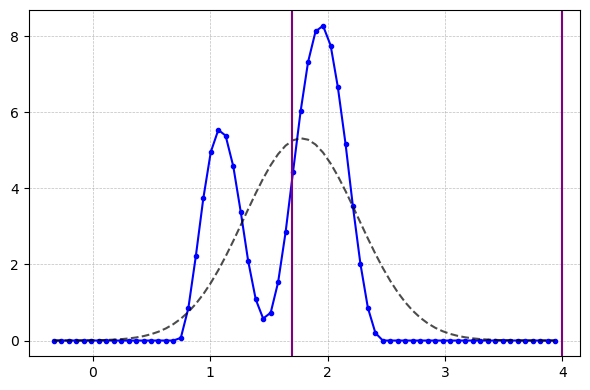

-- Melina DLS Replica --
NAME       : R2.313
CODE       : R2
NUMBER     : 313
DATA_LEN   : 68
DISTANCE   : 8.1116
EXPERIMENT : ERM-313
COLLECTION : FormData Sampling



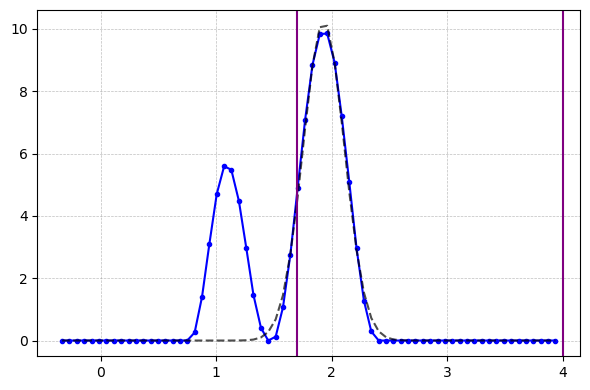

-- Melina DLS Replica --
NAME       : R3.313
CODE       : R3
NUMBER     : 313
DATA_LEN   : 68
DISTANCE   : 7.0584
EXPERIMENT : ERM-313
COLLECTION : FormData Sampling



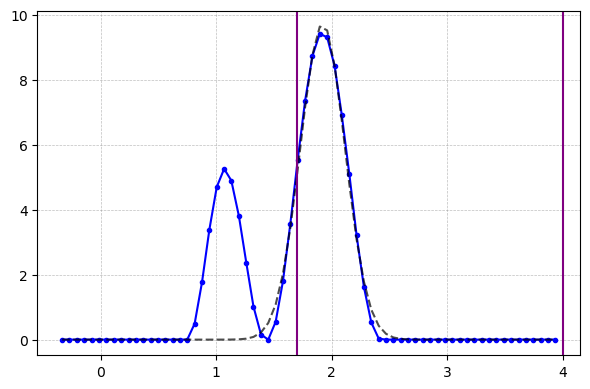

In [50]:
## Inspecció visual 
# es busca un experiment en específic i l'executa per a generar un gràfic 
# i veure com es comporten les dades respecte a l'ideal

found, debug_exp = formdata_sampling.find_experiment("ERM-313")
print(found)
print(debug_exp)

for rep in debug_exp.replicas:
    print(rep)
    rep.plot_fit()

True
-- Melina DLS Experiment --
NAME       : ERM-266
CODE       : ERM
NUMBER     : 266
REPLICAS   : 3
COLLECTION : Melina Sampling
DISTANCE : 34.8828

-- Melina DLS Replica --
NAME       : R1.266
CODE       : R1
NUMBER     : 266
DATA_LEN   : 68
DISTANCE   : 33.6612
EXPERIMENT : ERM-266
COLLECTION : Melina Sampling



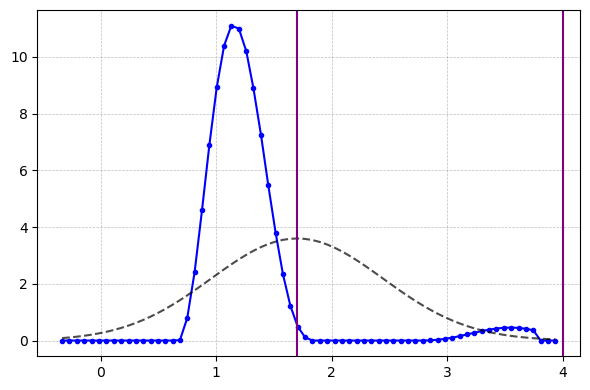

-- Melina DLS Replica --
NAME       : R2.266
CODE       : R2
NUMBER     : 266
DATA_LEN   : 68
DISTANCE   : 34.1233
EXPERIMENT : ERM-266
COLLECTION : Melina Sampling



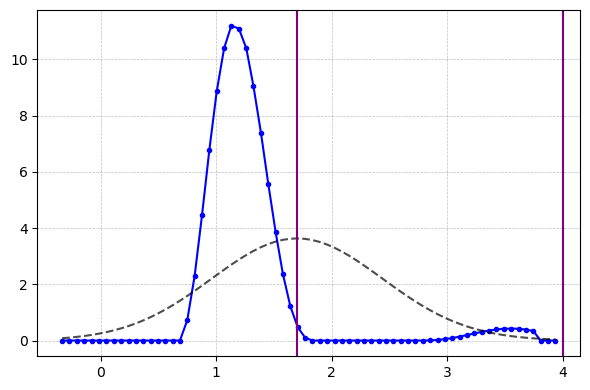

-- Melina DLS Replica --
NAME       : R3.266
CODE       : R3
NUMBER     : 266
DATA_LEN   : 68
DISTANCE   : 36.8638
EXPERIMENT : ERM-266
COLLECTION : Melina Sampling



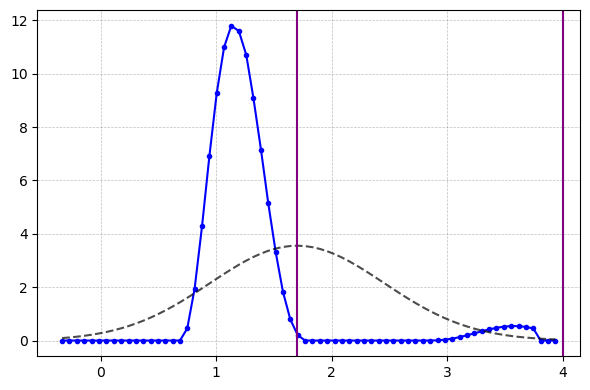

In [30]:
found, debug_exp = melina_sampling.find_experiment("ERM-266")
print(found)
print(debug_exp)

for rep in debug_exp.replicas:
    print(rep)
    rep.plot_fit()

Un cop has acabat, pots guardad tota la info en un fitxer binari, utilitzant la funció "save_binary"

Aqui estic guardant la Collection completa, que ja inclou tota la info guardada a les Repliques i Experiments

In [ ]:
save_binary(melina_sampling, "./Melina_Sampling.npy")

Per carregar les dades, pots utilitzar la funció "load_binary"

In [ ]:
loaded_melina_sampling = load_binary("./Melina_Sampling.npy")

I ja ho tens tot altre cop

In [ ]:
print(loaded_melina_sampling)

In [ ]:
rep = debug_exp.replicas[0] 

In [ ]:
rep

## Lectura de dades 

In [ ]:
import csv

# Path .csv
file = "/Users/Usuario/Desktop/MELINA\MELINA_results_rawdata.csv"

with open(file, newline="", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=";")
    data = list(reader)

# Stores data
header = data[1]
rows = data[0:]
columns = list(zip(*rows))

In [ ]:
## Creates Collection
melina_sampling = Collection("Melina Sampling")
print(melina_sampling)

In [ ]:
## Creates Experiments
for col in columns[1:]:
    if col[0] != '': 
        melina_sampling.add_experiment(col[0], debug=0)
print(melina_sampling)

In [ ]:
## Adds Replicas to Corresponding Experiment
for col in columns[1:]:
    exp_name = col[0]
    rep_name = col[1]
    x_data   = columns[0][1:]
    y_data   = col[1:]
    found, experiment = melina_sampling.find_experiment(rep_name, debug=0)
    if found: experiment.add_replica(rep_name, x_data, y_data, debug=0)
    else: print(f"Experiment {col[1]} not found")

## Revisem dades i fitegem

In [ ]:
found, test_exp = melina_sampling.find_experiment("ERM-262")

In [ ]:
## Parametres del Fitting. Serveixen per representar la distribució 'ideal'
mu_bounds    = [1.7,4]   ## En escala logaritmica
#sigma_bounds = [0.05, 0.06]
#sigma_init   = 0.055

for exp in melina_sampling.experiments:
    for rep in exp.replicas:
        rep.fit_data(mu_bounds=mu_bounds, debug=0)
        print(exp.name, rep.name, rep.distance)

In [ ]:
for exp in melina_sampling.experiments:
    print(exp.name, exp.distance)

In [ ]:
found, debug_exp = melina_sampling.find_experiment("ERM-268")
print(found)
print(debug_exp)

for rep in debug_exp.replicas:
    print(rep)
    rep.plot_fit()

In [ ]:
found, debug_exp = melina_sampling.find_experiment("ERM-266")
print(found)
print(debug_exp)

for rep in debug_exp.replicas:
    print(rep)
    rep.plot_fit()

Un cop has acabat, pots guardad tota la info en un fitxer binari, utilitzant la funció "save_binary"

Aqui estic guardant la Collection completa, que ja inclou tota la info guardada a les Repliques i Experiments

In [ ]:
save_binary(melina_sampling, "./Melina_Sampling.npy")

Per carregar les dades, pots utilitzar la funció "load_binary"

In [ ]:
loaded_melina_sampling = load_binary("./Melina_Sampling.npy")

I ja ho tens tot altre cop

In [ ]:
print(loaded_melina_sampling)

In [ ]:
rep = debug_exp.replicas[0]

In [ ]:
rep